# TP4: CLASIFICANDO INFORMALES EN LA EPH: MÉTODOS DE REGULARIZACIÓN & CART
## Taller de Programación - UBA
## Grupo 4
---

### Cargamos las bases, controles y ajuste de predictores

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

drive.mount('/content/drive', force_remount=True)

ruta_proyecto = "/content/drive/MyDrive/Taller de Programación '26"
ruta_bases_tp3 = os.path.join(ruta_proyecto, "bases_TP3")

Mounted at /content/drive


In [ ]:
ocupados_X_2025_MM = pd.read_pickle(os.path.join(ruta_bases_tp3, "ocupados_X_2025_MM.pkl"))
y_2025_MM = pd.read_pickle(os.path.join(ruta_bases_tp3, "y_2025_MM.pkl"))

print("Bases cargadas correctamente:")
print("ocupados_X_2025_MM:", ocupados_X_2025_MM.shape)
print("y_2025_MM:", y_2025_MM.shape)

Bases cargadas correctamente:
ocupados_X_2025_MM: (1564, 22)
y_2025_MM: (1564,)


In [ ]:
print("\nCantidad de predictores:", ocupados_X_2025_MM.shape[1])
print("Incluye informal_2024:",'informal_2024' in ocupados_X_2025_MM.columns)
print("NaN en X:",ocupados_X_2025_MM.isna().sum().sum())
print("NaN en y:",y_2025_MM.isna().sum())
display(ocupados_X_2025_MM.head())


Cantidad de predictores: 22
Incluye informal_2024: True
NaN en X: 0
NaN en y: 0


,mujer,jefe_hogar,conyuge_pareja,hijo_hogar,con_pareja,tiene_cobertura_medica,patron,sector_informal,establecimiento_6_a_40_personas,establecimiento_mas_40_personas,...,region_cuyo,region_pampeana,region_patagonia,CH06,P21_2025T4,edad2,educ,horastrabj,nhogar,informal_2024
0,0,0,1,0,1,1,0,0,0,0,...,0,1,0,34.0,1140000.0,1156.0,8.0,36.0,4.0,1
1,1,0,0,1,0,0,0,1,0,0,...,0,1,0,45.0,400000.0,2025.0,9.0,0.0,3.0,1
2,0,1,0,0,0,1,1,0,1,0,...,0,0,0,62.0,2000000.0,3844.0,7.0,44.0,4.0,1
3,0,1,0,0,1,1,1,0,0,0,...,0,0,0,53.0,1900000.0,2809.0,17.0,40.0,4.0,0
4,0,0,1,0,1,1,0,0,0,0,...,0,1,0,43.0,1250000.0,1849.0,12.0,44.0,4.0,1


Por recomendación de Noelia en la clase se deja afuera las horas trabajadas y el ingreso. Dado que en nuestra definición de informalidad incluimos si es patrón y el tamaño del establecimiento, estas también se dejan afuera.

In [ ]:
variables_excluir = [
    'P21_2025T4',
    'horastrabj',
    'patron',
    'establecimiento_6_a_40_personas',
    'establecimiento_mas_40_personas'
]

X = ocupados_X_2025_MM.drop(
    columns=variables_excluir
).copy()

y = y_2025_MM.astype(int).copy()

print("Dimensión de X:", X.shape)
print("Cantidad de predictores:", X.shape[1])

Dimensión de X: (1564, 17)
Cantidad de predictores: 17


## Estandarización

In [ ]:
variables_numericas = ['CH06','edad2','educ','nhogar']

X_num = X[variables_numericas].astype('float64').copy()

In [ ]:
variables_dummies = [
    col for col in X.columns
    if col not in variables_numericas
]

X_dummies = X[variables_dummies].astype(float).copy()

In [ ]:
sc = StandardScaler()

X_transformed = pd.DataFrame(
    sc.fit_transform(X_num),
    index=X_num.index,
    columns=X_num.columns
)

In [ ]:
X_reg = pd.concat([X_transformed,X_dummies],axis=1)

X_reg = X_reg[X.columns]

In [ ]:
X_reg.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
mujer,1564.0,0.39,0.49,0.00,0.00,0.00,1.00,1.00
jefe_hogar,1564.0,0.56,0.50,0.00,0.00,1.00,1.00,1.00
conyuge_pareja,1564.0,0.25,0.43,0.00,0.00,0.00,0.00,1.00
hijo_hogar,1564.0,0.15,0.35,0.00,0.00,0.00,0.00,1.00
con_pareja,1564.0,0.62,0.49,0.00,0.00,1.00,1.00,1.00
tiene_cobertura_medica,1564.0,0.55,0.50,0.00,0.00,1.00,1.00,1.00
sector_informal,1564.0,0.57,0.49,0.00,0.00,1.00,1.00,1.00
region_noroeste,1564.0,0.23,0.42,0.00,0.00,0.00,0.00,1.00
region_noreste,1564.0,0.11,0.31,0.00,0.00,0.00,0.00,1.00
region_cuyo,1564.0,0.11,0.31,0.00,0.00,0.00,0.00,1.00


In [ ]:
print("Dimensión final de X:", X_reg.shape)
print("Dimensión de y:", y.shape)
print("\nNaN en X:", X_reg.isna().sum().sum())
print("NaN en y:", y.isna().sum())
print("\nVariables numéricas estandarizadas:", variables_numericas)
print("\nCantidad de variables binarias sin estandarizar:", len(variables_dummies))
print("\nValores de informal_2024:",sorted(X_reg['informal_2024'].unique()))

Dimensión final de X: (1564, 17)
Dimensión de y: (1564,)

NaN en X: 0
NaN en y: 0

Variables numéricas estandarizadas: ['CH06', 'edad2', 'educ', 'nhogar']

Cantidad de variables binarias sin estandarizar: 13

Valores de informal_2024: [np.float64(0.0), np.float64(1.0)]


### Etiquetas de las variables de `X_reg`

In [ ]:
labels_X_reg = {
    'mujer': 'Mujer',
    'jefe_hogar': 'Jefe/a de Hogar',
    'conyuge_pareja': 'Cónyuge/Pareja',
    'hijo_hogar': 'Hijo/a de Hogar',
    'con_pareja': 'Con Pareja',
    'tiene_cobertura_medica': 'Tiene Cobertura Médica',
    'sector_informal': 'Sector Informal',
    'region_noroeste': 'Región Noroeste',
    'region_noreste': 'Región Noreste',
    'region_cuyo': 'Región Cuyo',
    'region_pampeana': 'Región Pampeana',
    'region_patagonia': 'Región Patagonia',
    'CH06': 'Edad',
    'edad2': 'Edad al Cuadrado',
    'educ': 'Años de educación',
    'nhogar': 'Número de Miembros en Hogar',
    'informal_2024': 'Informal en 2024'
}

etiquetas_df = pd.DataFrame.from_dict(labels_X_reg, orient='index', columns=['Descripción'])
etiquetas_df.index.name = 'Variable'
display(etiquetas_df)

,Descripción
Variable,
mujer,Mujer
jefe_hogar,Jefe/a de Hogar
conyuge_pareja,Cónyuge/Pareja
hijo_hogar,Hijo/a de Hogar
con_pareja,Con Pareja
tiene_cobertura_medica,Tiene Cobertura Médica
sector_informal,Sector Informal
region_noroeste,Región Noroeste
region_noreste,Región Noreste


## A. Modelo de Regresión Logística con Regularización: Ridge y LASSO


### A.1 Visualización

Grilla de lambda solicitada en la consigna, estimo LASSO y Ridge para toda la grilla

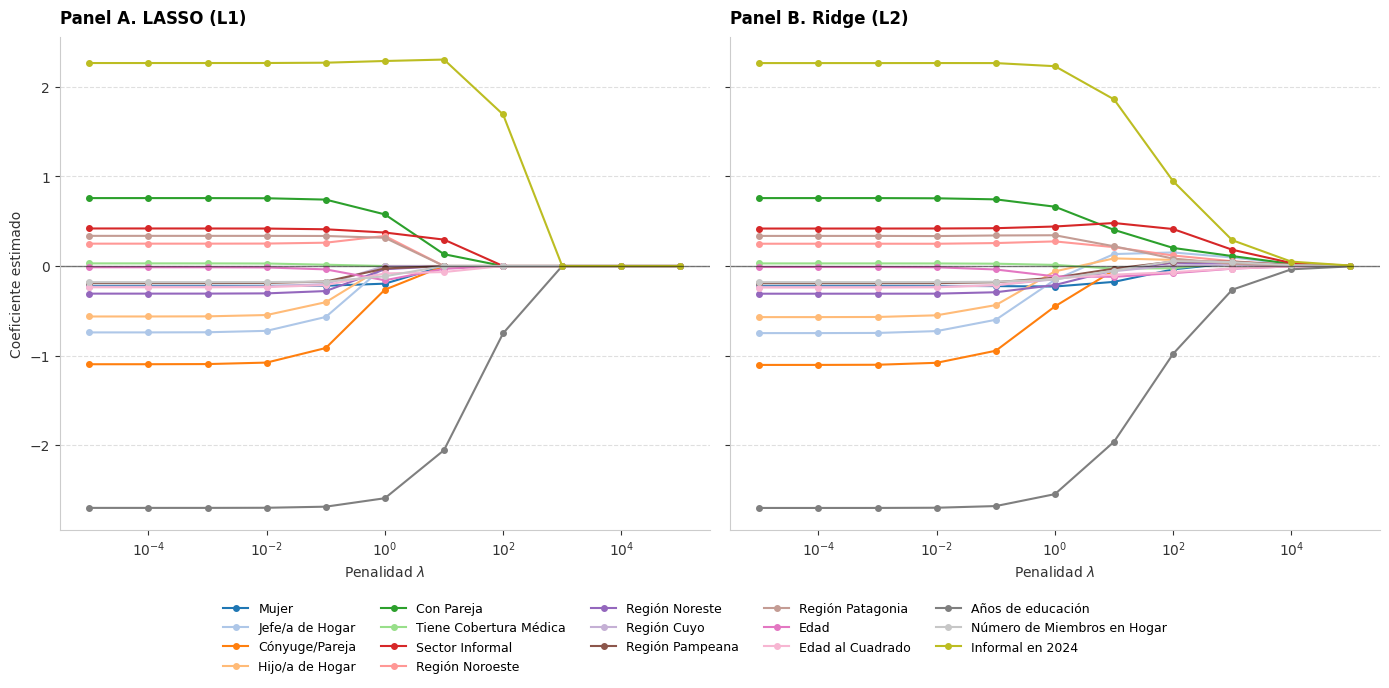

In [ ]:
# 1. Definimos la grilla de penalización (lambdas)
n = np.arange(-5, 6)
lambdas = 10.0 ** n
Cs = 1 / lambdas

# 2. Estimamos los modelos LASSO y Ridge para cada valor de la grilla
coef_lasso, coef_ridge = [], []

for C in Cs:
    # LASSO
    modelo_lasso = LogisticRegression(penalty='l1', C=C, solver='liblinear', max_iter=10000, random_state=123)
    modelo_lasso.fit(X_reg, y)
    coef_lasso.append(modelo_lasso.coef_[0])

    # Ridge
    modelo_ridge = LogisticRegression(penalty='l2', C=C, solver='liblinear', max_iter=10000, random_state=123)
    modelo_ridge.fit(X_reg, y)
    coef_ridge.append(modelo_ridge.coef_[0])

# 3. Convertimos las listas en arrays para facilitar el gráfico
coef_lasso = np.array(coef_lasso)
coef_ridge = np.array(coef_ridge)

# 4. Visualización: Trayectoria de los coeficientes
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
colores = plt.cm.tab20.colors

# --- Panel A: LASSO ---
for j, variable in enumerate(X_reg.columns):
    axes[0].plot(lambdas, coef_lasso[:, j], marker='o', markersize=4,
                 linewidth=1.5, color=colores[j % 20], label=labels_X_reg[variable])

axes[0].set_xscale('log')
axes[0].axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)
axes[0].set_xlabel(r'Penalidad $\lambda$', color='#333333')
axes[0].set_ylabel('Coeficiente estimado', color='#333333')
axes[0].set_title('Panel A. LASSO (L1)', loc='left', fontweight='bold', pad=10)

# --- Panel B: Ridge ---
for j, variable in enumerate(X_reg.columns):
    axes[1].plot(lambdas, coef_ridge[:, j], marker='o', markersize=4,
                 linewidth=1.5, color=colores[j % 20], label=labels_X_reg[variable])

axes[1].set_xscale('log')
axes[1].axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)
axes[1].set_xlabel(r'Penalidad $\lambda$', color='#333333')
axes[1].set_title('Panel B. Ridge (L2)', loc='left', fontweight='bold', pad=10)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.grid(axis='x', visible=False)
    ax.tick_params(colors='#333333')

# Leyenda
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15),
           ncol=5, frameon=False, fontsize=9)


plt.tight_layout()
plt.show()

In [ ]:
nombre_archivo = os.path.join(ruta_tp4, 'coeficientes_lasso_ridge.png')
fig.savefig(nombre_archivo, bbox_inches='tight', dpi=300)
print(f"Gráfico guardado en: {nombre_archivo}")

Gráfico guardado en: /content/drive/MyDrive/Taller de Programación '26/TP4/coeficientes_lasso_ridge.png


### A.2 Penalidad óptima por Cross-validation y visualización

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold

In [ ]:
cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

Cross validation para LASSO

In [ ]:
lasso_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=cv_5,
    penalty='l1',
    solver='liblinear',
    scoring='accuracy',
    max_iter=10000,
    random_state=123,
    refit=True
)

lasso_cv.fit(X_reg, y)

# C óptimo seleccionado por CV
C_cv_lasso = lasso_cv.C_[0]

# Como C = 1/lambda
lambda_cv_lasso = 1 / C_cv_lasso

print("C óptimo LASSO:", C_cv_lasso)
print("Lambda óptimo LASSO:", lambda_cv_lasso)

C óptimo LASSO: 1.0
Lambda óptimo LASSO: 1.0


Cross validation para Ridge

In [ ]:
ridge_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=cv_5,
    penalty='l2',
    solver='liblinear',
    scoring='accuracy',
    max_iter=10000,
    random_state=123,
    refit=True
)

ridge_cv.fit(X_reg, y)

# C óptimo seleccionado por CV
C_cv_ridge = ridge_cv.C_[0]

# Como C = 1/lambda
lambda_cv_ridge = 1 / C_cv_ridge

print("C óptimo Ridge:", C_cv_ridge)
print("Lambda óptimo Ridge:", lambda_cv_ridge)

C óptimo Ridge: 99999.99999999999
Lambda óptimo Ridge: 1e-05


Recupero los errores de los 5-fold

In [ ]:
scores_lasso = list(lasso_cv.scores_.values())[0]
scores_ridge = list(ridge_cv.scores_.values())[0]

print("Dimensión scores LASSO:", scores_lasso.shape)
print("Dimensión scores Ridge:", scores_ridge.shape)

Dimensión scores LASSO: (5, 11)
Dimensión scores Ridge: (5, 11)


Error de clasificación = 1 - accuracy

In [ ]:
errores_lasso = 1 - scores_lasso
errores_ridge = 1 - scores_ridge

Tabla resumen por λ

In [ ]:
resultados_cv = pd.DataFrame({
    'lambda': lambdas,
    'C': Cs,
    'error_medio_lasso': errores_lasso.mean(axis=0),
    'error_medio_ridge': errores_ridge.mean(axis=0)
})

resultados_cv

,lambda,C,error_medio_lasso,error_medio_ridge
0,0.00001,100000.00000,0.076094,0.076094
1,0.00010,10000.00000,0.076094,0.076094
2,0.00100,1000.00000,0.076094,0.076094
3,0.01000,100.00000,0.076094,0.076094
4,0.10000,10.00000,0.076094,0.076094
5,1.00000,1.00000,0.074818,0.076735
6,10.00000,0.10000,0.083763,0.076735
7,100.00000,0.01000,0.092713,0.099105
8,1000.00000,0.00100,0.783888,0.184144
9,10000.00000,0.00010,0.783888,0.214193


In [ ]:
print("Menor error promedio LASSO:",resultados_cv['error_medio_lasso'].min())
print("Menor error promedio Ridge:",resultados_cv['error_medio_ridge'].min())

Menor error promedio LASSO: 0.07481772753338249
Menor error promedio Ridge: 0.0760936347997051


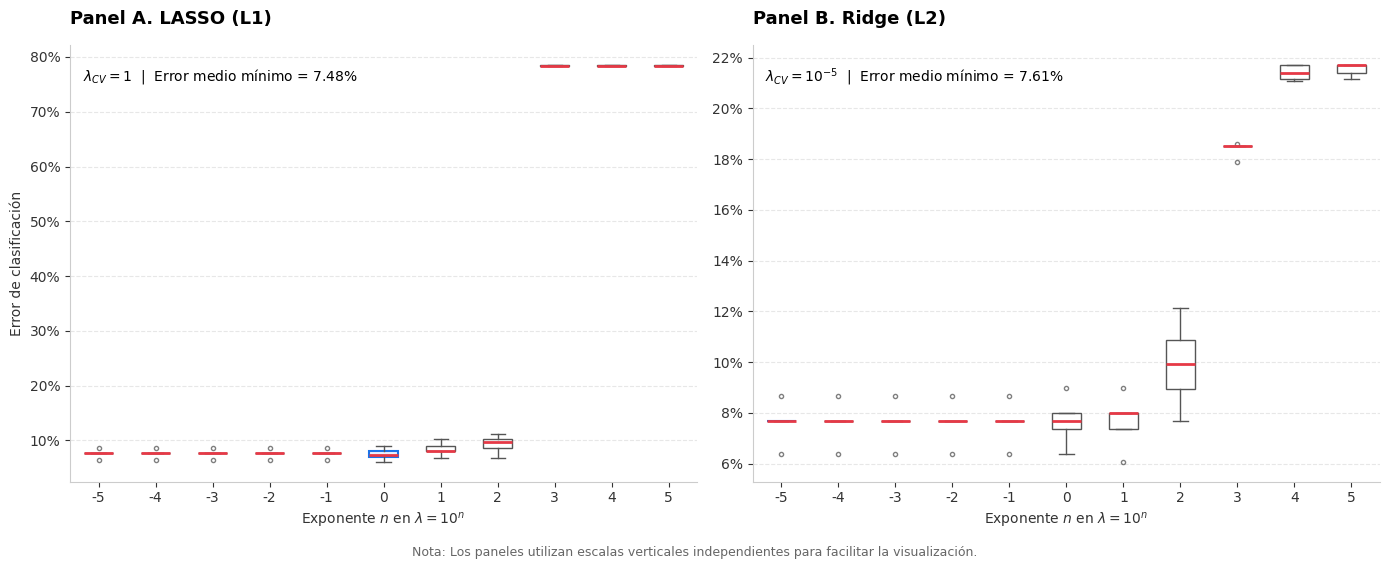

In [ ]:
from matplotlib.ticker import PercentFormatter

# --- CÁLCULO DE LOS ÍNDICES Y MÍNIMOS ---
idx_lasso = np.where(np.isclose(lambdas, lambda_cv_lasso))[0][0]
idx_ridge = np.where(np.isclose(lambdas, lambda_cv_ridge))[0][0]
min_lasso = resultados_cv['error_medio_lasso'].min()
min_ridge = resultados_cv['error_medio_ridge'].min()
# ----------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
posiciones = np.arange(len(lambdas))
labels_lambda = [str(exp) for exp in n]

def grafico_cv(ax, errores, idx_seleccionado, titulo, texto_resultado):
    bp = ax.boxplot(
        [errores[:, j] for j in range(len(lambdas))],
        positions=posiciones,
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor='white', color='#555555', linewidth=1),
        whiskerprops=dict(color='#555555', linewidth=1),
        capprops=dict(color='#555555', linewidth=1),
        medianprops=dict(color='#E63946', linewidth=2),
        flierprops=dict(marker='.', color='#555555', alpha=0.5)
    )

    # Resaltar el boxplot del lambda óptimo
    bp['boxes'][idx_seleccionado].set_facecolor('#E8F0FE')
    bp['boxes'][idx_seleccionado].set_edgecolor('#1A73E8')
    bp['boxes'][idx_seleccionado].set_linewidth(1.5)

    # Formato de ejes
    ax.set_title(titulo, fontsize=13, fontweight='bold', loc='left', pad=15)
    ax.set_xticks(posiciones)
    ax.set_xticklabels(labels_lambda)
    ax.set_xlabel(r'Exponente $n$ en $\lambda = 10^n$', color='#333333')

    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(colors='#333333')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.grid(axis='x', visible=False)

    ax.text(0.02, 0.95, texto_resultado, transform=ax.transAxes, ha='left', va='top',
            fontsize=10, bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

# --- Panel LASSO ---
grafico_cv(axes[0], errores_lasso, idx_lasso, 'Panel A. LASSO (L1)',
           rf'$\lambda_{{CV}} = {lambda_cv_lasso:g}$  |  Error medio mínimo = {min_lasso:.2%}')
axes[0].set_ylabel('Error de clasificación', color='#333333')

# --- Panel Ridge ---
grafico_cv(axes[1], errores_ridge, idx_ridge, 'Panel B. Ridge (L2)',
           rf'$\lambda_{{CV}} = 10^{{-5}}$  |  Error medio mínimo = {min_ridge:.2%}')


fig.text(0.5, -0.02, 'Nota: Los paneles utilizan escalas verticales independientes para facilitar la visualización.',
         ha='center', fontsize=9, color='#666666')

plt.tight_layout()
plt.show()

In [ ]:
print("Penalidades óptimas seleccionadas por Cross-Validation:")
print(f"LASSO: lambda_cv = {lambda_cv_lasso:g}")
print(f"Ridge: lambda_cv = {lambda_cv_ridge:g}")

Penalidades óptimas seleccionadas por Cross-Validation:
LASSO: lambda_cv = 1
Ridge: lambda_cv = 1e-05


### A.3 Estimación con 𝜆𝑐𝑣 y comparación de coeficientes

Regresión logística sin penalización

In [ ]:
modelo_logit = LogisticRegression(
    penalty=None,
    solver='lbfgs',
    max_iter=10000,
    random_state=123
)

modelo_logit.fit(X_reg, y)

LogisticRegression(max_iter=10000, penalty=None, random_state=123)

In [ ]:
import statsmodels.api as sm

# Agrego constante para el intercepto
X_logit_sm = sm.add_constant(X_reg)

# Estimo el Logit sin penalización con statsmodels
# para obtener los errores estándar
logit_sm = sm.Logit(
    y,
    X_logit_sm
).fit(
    disp=False,
    maxiter=10000
)

# Errores estándar de los coeficientes
# Excluyo el intercepto
errores_estandar_logit = (
    logit_sm.bse
    .drop('const')
    .reindex(X_reg.columns)
)

errores_estandar_logit

,0
mujer,0.225190
jefe_hogar,0.687584
conyuge_pareja,0.737188
hijo_hogar,0.691623
con_pareja,0.310918
tiene_cobertura_medica,0.290462
sector_informal,0.271413
region_noroeste,0.377078
region_noreste,0.437355
region_cuyo,0.414833


LASSO con lambda óptimo seleccionado por CV

In [ ]:
modelo_lasso_cv = LogisticRegression(
    penalty='l1',
    C=C_cv_lasso,
    solver='liblinear',
    max_iter=10000,
    random_state=123
)

modelo_lasso_cv.fit(X_reg, y)

LogisticRegression(C=np.float64(1.0), max_iter=10000, penalty='l1',
                   random_state=123, solver='liblinear')

Ridge con lambda óptimo seleccionado por CV

In [ ]:
modelo_ridge_cv = LogisticRegression(
    penalty='l2',
    C=C_cv_ridge,
    solver='liblinear',
    max_iter=10000,
    random_state=123
)

modelo_ridge_cv.fit(X_reg, y)

LogisticRegression(C=np.float64(99999.99999999999), max_iter=10000,
                   random_state=123, solver='liblinear')

Generamos la tabla

In [ ]:
tabla_coeficientes = pd.DataFrame({
    'Variable': X_reg.columns.map(labels_X_reg),
    'Logit sin penalidad': modelo_logit.coef_[0],
    'EE Logit': errores_estandar_logit.values,
    'LASSO': modelo_lasso_cv.coef_[0],
    'Ridge': modelo_ridge_cv.coef_[0]
})

tabla_coeficientes

,Variable,Logit sin penalidad,EE Logit,LASSO,Ridge
0,Mujer,-0.223830,0.225190,-0.197022,-0.221288
1,Jefe/a de Hogar,-0.743602,0.687584,0.000000,-0.748810
2,Cónyuge/Pareja,-1.096575,0.737188,-0.263827,-1.103940
3,Hijo/a de Hogar,-0.572356,0.691623,0.000000,-0.570420
4,Con Pareja,0.751658,0.310918,0.576047,0.758034
5,Tiene Cobertura Médica,0.029451,0.290462,0.000000,0.028944
6,Sector Informal,0.420673,0.271413,0.373715,0.418197
7,Región Noroeste,0.238898,0.377078,0.335605,0.248661
8,Región Noreste,-0.313840,0.437355,-0.035842,-0.308992
9,Región Cuyo,-0.236348,0.414833,0.000000,-0.232060


In [ ]:
comparacion_coeficientes = tabla_coeficientes.copy()

comparacion_coeficientes['|Logit|'] = abs(
    comparacion_coeficientes['Logit sin penalidad']
)

comparacion_coeficientes['|LASSO|'] = abs(
    comparacion_coeficientes['LASSO']
)

comparacion_coeficientes['|Ridge|'] = abs(
    comparacion_coeficientes['Ridge']
)

comparacion_coeficientes['LASSO = 0'] = np.isclose(
    comparacion_coeficientes['LASSO'],
    0,
    atol=1e-8
)

comparacion_coeficientes['Ridge = 0'] = np.isclose(
    comparacion_coeficientes['Ridge'],
    0,
    atol=1e-8
)

comparacion_coeficientes

,Variable,Logit sin penalidad,EE Logit,LASSO,Ridge,|Logit|,|LASSO|,|Ridge|,LASSO = 0,Ridge = 0
0,mujer,-0.223830,0.225190,-0.197022,-0.221288,0.223830,0.197022,0.221288,False,False
1,jefe_hogar,-0.743602,0.687584,0.000000,-0.748810,0.743602,0.000000,0.748810,True,False
2,conyuge_pareja,-1.096575,0.737188,-0.263827,-1.103940,1.096575,0.263827,1.103940,False,False
3,hijo_hogar,-0.572356,0.691623,0.000000,-0.570420,0.572356,0.000000,0.570420,True,False
4,con_pareja,0.751658,0.310918,0.576047,0.758034,0.751658,0.576047,0.758034,False,False
5,tiene_cobertura_medica,0.029451,0.290462,0.000000,0.028944,0.029451,0.000000,0.028944,True,False
6,sector_informal,0.420673,0.271413,0.373715,0.418197,0.420673,0.373715,0.418197,False,False
7,region_noroeste,0.238898,0.377078,0.335605,0.248661,0.238898,0.335605,0.248661,False,False
8,region_noreste,-0.313840,0.437355,-0.035842,-0.308992,0.313840,0.035842,0.308992,False,False
9,region_cuyo,-0.236348,0.414833,0.000000,-0.232060,0.236348,0.000000,0.232060,True,False


In [ ]:
print("Variables eliminadas por LASSO:",comparacion_coeficientes['LASSO = 0'].sum())
print("Variables eliminadas por Ridge:",comparacion_coeficientes['Ridge = 0'].sum())

Variables eliminadas por LASSO: 4
Variables eliminadas por Ridge: 0


Para ver cuales eliminó LASSO

In [ ]:
variables_eliminadas_lasso = comparacion_coeficientes.loc[
    comparacion_coeficientes['LASSO = 0'],
    'Variable'
].tolist()

print("Variables eliminadas por LASSO:")
print(variables_eliminadas_lasso)

Variables eliminadas por LASSO:
['jefe_hogar', 'hijo_hogar', 'tiene_cobertura_medica', 'region_cuyo']


In [ ]:
comparacion_coeficientes['LASSO achica'] = (comparacion_coeficientes['|LASSO|']<= comparacion_coeficientes['|Logit|'])
comparacion_coeficientes['Ridge achica'] = (comparacion_coeficientes['|Ridge|'] <= comparacion_coeficientes['|Logit|'])

print(
    "Coeficientes más pequeños con LASSO:",
    comparacion_coeficientes['LASSO achica'].sum(),
    "de",
    len(comparacion_coeficientes)
)

print(
    "Coeficientes más pequeños con Ridge:",
    comparacion_coeficientes['Ridge achica'].sum(),
    "de",
    len(comparacion_coeficientes)
)

Coeficientes más pequeños con LASSO: 14 de 17
Coeficientes más pequeños con Ridge: 9 de 17


Exporto la tabla de coeficientes:

In [ ]:
tabla_coeficientes_export = tabla_coeficientes.copy()

tabla_coeficientes_export[
    ['Logit sin penalidad', 'EE Logit', 'LASSO', 'Ridge']
] = tabla_coeficientes_export[
    ['Logit sin penalidad', 'EE Logit', 'LASSO', 'Ridge']
].round(4)

ruta_tp4 = os.path.join(ruta_proyecto, "TP4")
os.makedirs(ruta_tp4, exist_ok=True)

tabla_coeficientes_export.to_excel(
    os.path.join(ruta_tp4, "tabla_coeficientes_A3.xlsx"),
    index=False
)

## B. Árboles



### B.1 Estimación de CART

El ccp_alpha óptimo seleccionado por 5-fold CV es: 0.003543


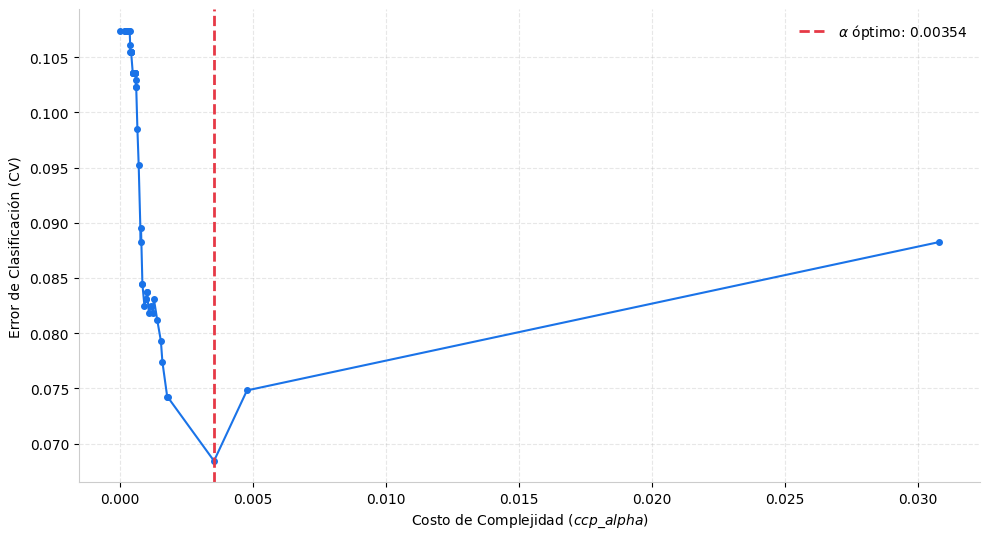

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# ------------------------------------------------------------
# 1. Extraemos el "camino de poda" (ccp_alphas posibles)
# ------------------------------------------------------------

arbol_inicial = DecisionTreeClassifier(random_state=123)
path = arbol_inicial.cost_complexity_pruning_path(X_reg, y)
ccp_alphas = path.ccp_alphas

# Descartamos el último alpha porque poda el árbol hasta dejar solo el nodo raíz
ccp_alphas = ccp_alphas[:-1]


# ------------------------------------------------------------
# 2. Búsqueda en grilla con 5-Fold Cross-Validation
# ------------------------------------------------------------

arbol = DecisionTreeClassifier(random_state=123)
grid_search = GridSearchCV(
    estimator=arbol,
    param_grid={'ccp_alpha': ccp_alphas},
    cv=cv_5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_reg, y)

# 3. Extraemos el alpha óptimo y los errores medios (1 - accuracy)
alpha_optimo = grid_search.best_params_['ccp_alpha']
errores_cv = 1 - grid_search.cv_results_['mean_test_score']

print(f"El ccp_alpha óptimo seleccionado por 5-fold CV es: {alpha_optimo:.6f}")

# Guardamos el mejor modelo ya entrenado para usarlo después
modelo_arbol_cv = grid_search.best_estimator_


# ------------------------------------------------------------
# 4. Gráfico: Error de clasificación vs ccp_alpha
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    ccp_alphas,
    errores_cv,
    marker='o',
    markersize=4,
    color='#1A73E8',
    linewidth=1.5
)

# Línea vertical marcando el mínimo error
ax.axvline(
    x=alpha_optimo,
    color='#E63946',
    linestyle='--',
    linewidth=2,
    label=f'$\\alpha$ óptimo: {alpha_optimo:.5f}'
)

ax.set_xlabel(r'Costo de Complejidad ($ccp\_alpha$)')
ax.set_ylabel('Error de Clasificación (CV)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.grid(axis='x', linestyle='--', alpha=0.3)

ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

### B.2 Visualización del árbol podado por cross-validation

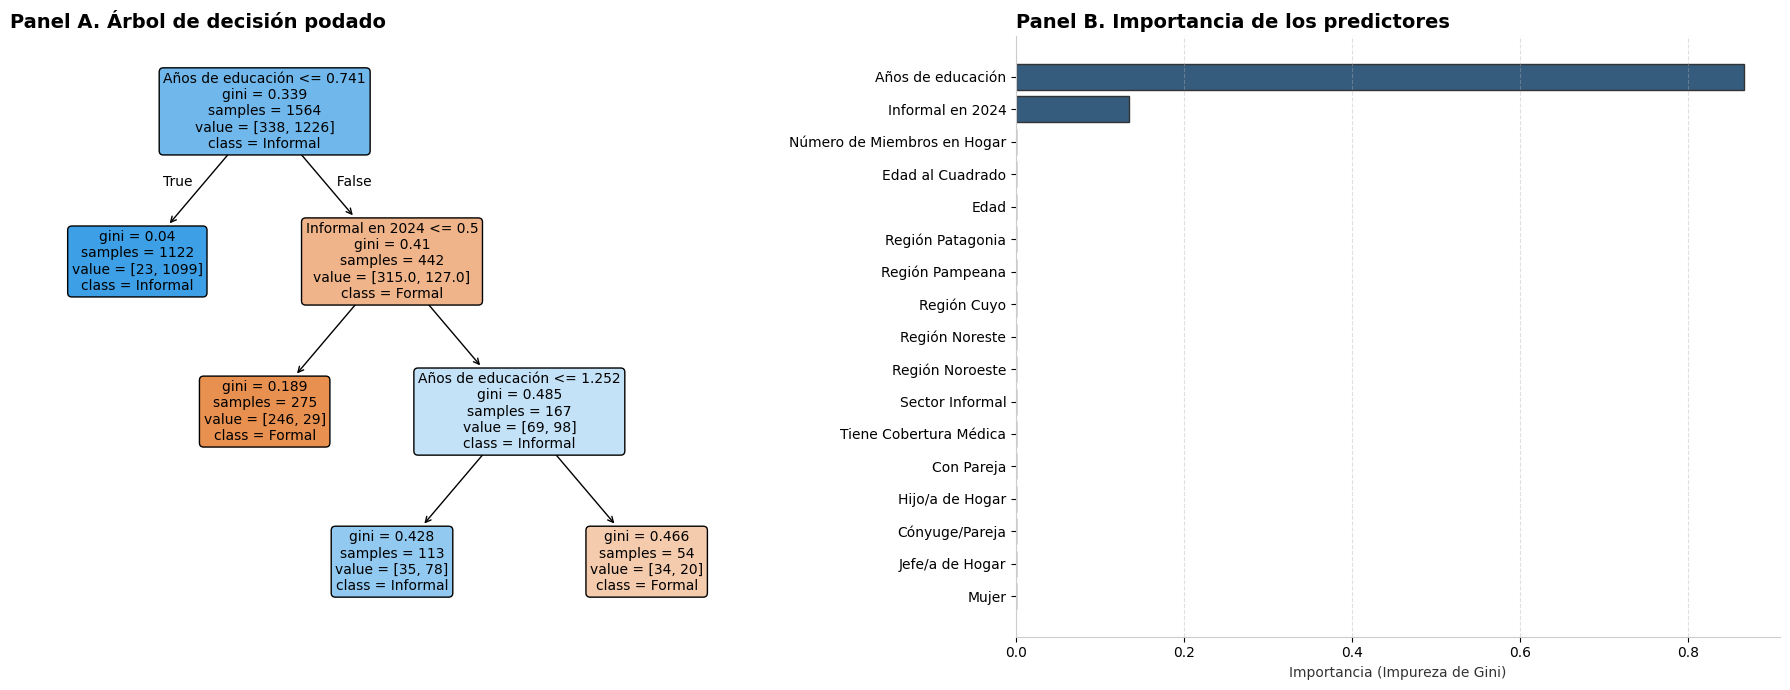

In [ ]:
from sklearn.tree import plot_tree

# 1. Extraigo la importancia de los predictores del modelo óptimo
importancias = pd.Series(
    modelo_arbol_cv.feature_importances_,
    index=X_reg.columns
).sort_values(ascending=True)

# 2. Inicializo la figura con dos paneles
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel A: Visualización del árbol podado ---
plot_tree(
    modelo_arbol_cv,
    feature_names=[labels_X_reg[col] for col in X_reg.columns],
    class_names=['Formal', 'Informal'], # y=0 Formal, y=1 Informal
    filled=True,
    rounded=True,
    fontsize=10,
    ax=axes[0]
)
axes[0].set_title('Panel A. Árbol de decisión podado', fontweight='bold', fontsize=14, loc='left')

# --- Panel B: Importancia de los predictores ---
axes[1].barh(
    importancias.index.map(labels_X_reg), # Modificado para usar etiquetas descriptivas
    importancias.values,
    color='#355C7D',
    edgecolor='#333333',
    linewidth=1
)
axes[1].set_xlabel('Importancia (Impureza de Gini)', color='#333333')
axes[1].set_title('Panel B. Importancia de los predictores', fontweight='bold', fontsize=14, loc='left')

# Formato estético del Panel B
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('#cccccc')
axes[1].spines['bottom'].set_color('#cccccc')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## C. Comparación de métodos
### Matriz de confusión

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

In [ ]:
modelos = {
    'Logit (Sin penalidad)': modelo_logit,
    'LASSO (L1)': modelo_lasso_cv,
    'Ridge (L2)': modelo_ridge_cv,
    'Árbol (CART)': modelo_arbol_cv
}

=== C.1 Desempeño de los modelos (5-fold CV, umbral p = 0.5) ===


,Accuracy,1 - Accuracy (Error),Sensibilidad (Identificar Informales),Especificidad (Identificar Formales),Falsos Positivos (FP),Falsos Negativos (FN)
Modelo,,,,,,
Logit (Sin penalidad),0.9246,0.0754,0.9625,0.7870,72,46
LASSO (L1),0.9252,0.0748,0.9625,0.7899,71,46
Ridge (L2),0.9239,0.0761,0.9617,0.7870,72,47
Árbol (CART),0.9316,0.0684,0.9600,0.8284,58,49


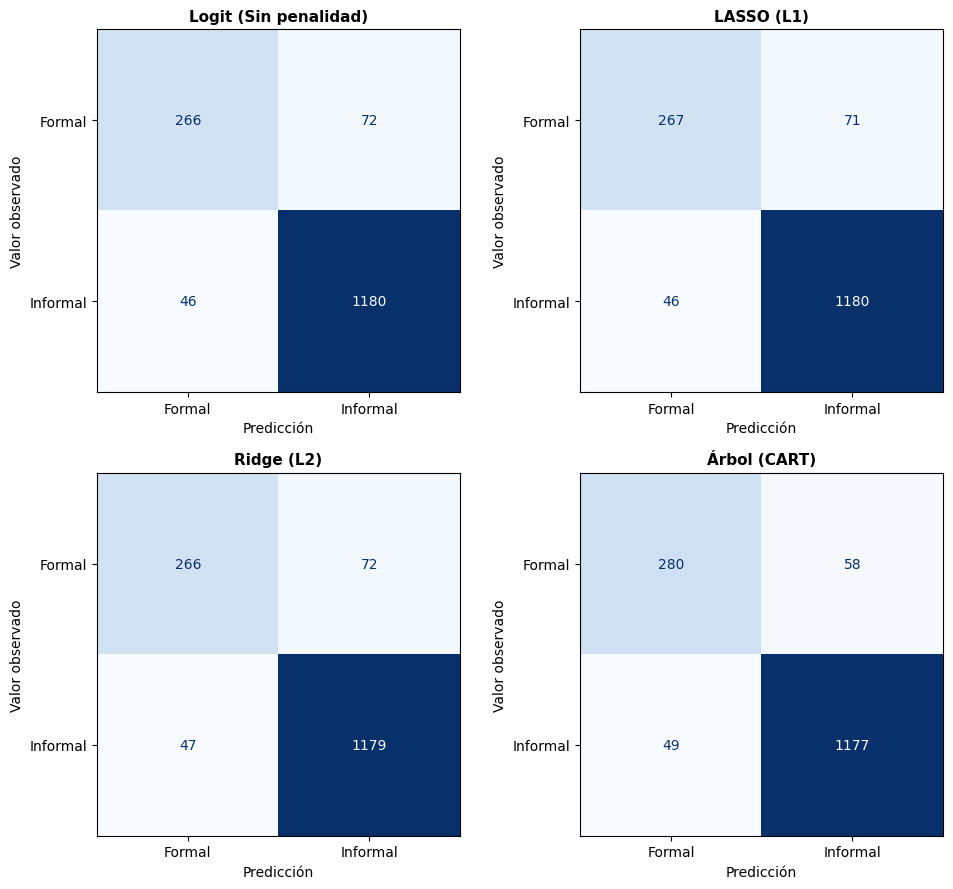

In [ ]:
predicciones = {}
probabilidades = {}

for nombre, modelo in modelos.items():

    # Probabilidades predichas mediante 5-fold CV
    prob = cross_val_predict(
        modelo,
        X_reg,
        y,
        cv=cv_5,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]

    # Clasificación usando el umbral solicitado p = 0.5
    pred = (prob >= 0.5).astype(int)

    probabilidades[nombre] = prob
    predicciones[nombre] = pred


# Genero metricas de desempeño

resultados_metricas = []

for nombre in modelos.keys():

    y_pred = predicciones[nombre]

    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(
        y,
        y_pred
    ).ravel()

    # Accuracy
    accuracy = accuracy_score(
        y,
        y_pred
    )

    # Error de clasificación solicitado en la consigna
    error_clasificacion = 1 - accuracy

    # Sensibilidad:
    # proporción de informales correctamente identificados
    sensibilidad = recall_score(
        y,
        y_pred
    )

    # Especificidad:
    # proporción de formales correctamente identificados
    especificidad = tn / (tn + fp)

    resultados_metricas.append({
        'Modelo': nombre,
        'Accuracy': accuracy,
        '1 - Accuracy (Error)': error_clasificacion,
        'Sensibilidad (Identificar Informales)': sensibilidad,
        'Especificidad (Identificar Formales)': especificidad,
        'Falsos Positivos (FP)': fp,
        'Falsos Negativos (FN)': fn
    })


tabla_metricas = (
    pd.DataFrame(resultados_metricas)
    .set_index('Modelo')
)

print(
    "=== C.1 Desempeño de los modelos "
    "(5-fold CV, umbral p = 0.5) ==="
)

display(
    tabla_metricas.round(4)
)


# Genero las matrices de confusión

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 9)
)

axes = axes.ravel()

for ax, nombre in zip(
    axes,
    modelos.keys()
):

    ConfusionMatrixDisplay.from_predictions(
        y,
        predicciones[nombre],
        display_labels=[
            'Formal',
            'Informal'
        ],
        colorbar=False,
        cmap='Blues',
        ax=ax
    )

    ax.set_title(
        nombre,
        fontsize=11,
        fontweight='bold'
    )

    ax.set_xlabel(
        'Predicción'
    )

    ax.set_ylabel(
        'Valor observado'
    )

plt.tight_layout()
plt.show()

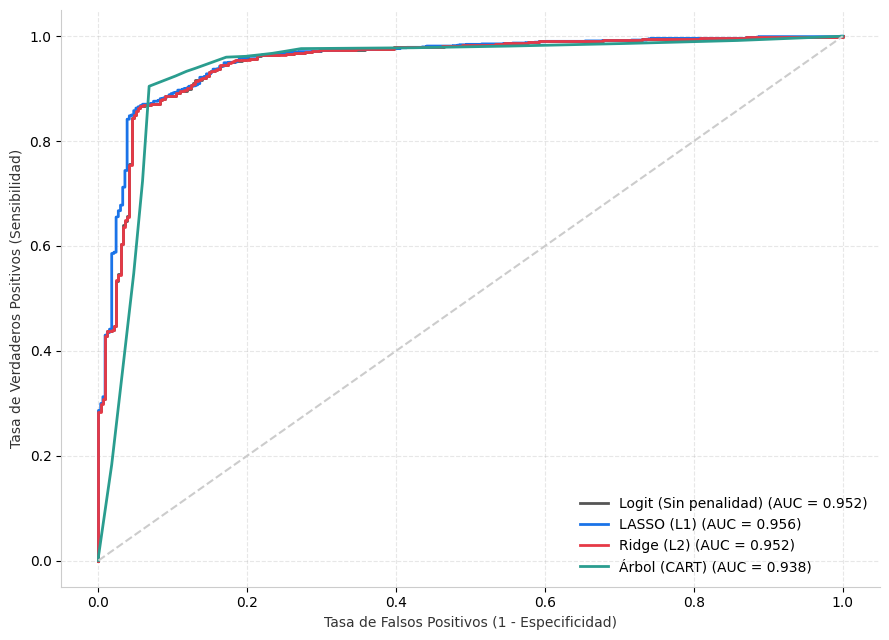

In [ ]:
#Curvas ROC

fig, ax = plt.subplots(
    figsize=(9, 6.5)
)

colores_roc = [
    '#555555',
    '#1A73E8',
    '#E63946',
    '#2A9D8F'
]

for (nombre, prob), color in zip(
    probabilidades.items(),
    colores_roc
):

    fpr, tpr, _ = roc_curve(
        y,
        prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    ax.plot(
        fpr,
        tpr,
        color=color,
        lw=2,
        label=f'{nombre} (AUC = {roc_auc:.3f})'
    )


# Línea de referencia: clasificación aleatoria
ax.plot(
    [0, 1],
    [0, 1],
    color='#cccccc',
    lw=1.5,
    linestyle='--'
)

ax.set_xlabel(
    'Tasa de Falsos Positivos (1 - Especificidad)',
    color='#333333'
)

ax.set_ylabel(
    'Tasa de Verdaderos Positivos (Sensibilidad)',
    color='#333333'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color(
    '#cccccc'
)

ax.spines['bottom'].set_color(
    '#cccccc'
)

ax.grid(
    axis='both',
    linestyle='--',
    alpha=0.3
)

ax.legend(
    frameon=False,
    loc='lower right',
    fontsize=10
)

plt.tight_layout()
plt.show()